In [190]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import nltk
import string
import re
nltk.download('punkt')
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("enron_spam_data.csv")



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\oraby\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [191]:
df.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [192]:
df.shape

(33716, 5)

In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 50.1 MB


In [194]:
df.duplicated().sum()

np.int64(0)

In [195]:
df.isnull().sum()

Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

# Cleaning Data

In [196]:
df = df.drop(columns=['Date','Message ID'])

In [197]:
df

,Subject,Message,Spam/Ham
0,christmas tree farm pictures,NaN,ham
1,"vastar resources , inc .","gary , production from the high island larger ...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham
3,re : issue,fyi - see note below - already done .\nstella\...,ham
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham
...,...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,"hello , welcome to gigapharm onlinne shop .\np...",spam
33712,all prescript medicines are on special . to be...,i got it earlier than expected and it was wrap...,spam
33713,the next generation online pharmacy .,are you ready to rock on ? let the man in you ...,spam
33714,bloow in 5 - 10 times the time,learn how to last 5 - 10 times longer in\nbed ...,spam


In [198]:
df["text"] = df["Subject"].fillna('') + " " + df["Message"].fillna('')

In [199]:
df

,Subject,Message,Spam/Ham,text
0,christmas tree farm pictures,NaN,ham,christmas tree farm pictures
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,"vastar resources , inc . gary , production fro..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,calpine daily gas nomination - calpine daily g...
3,re : issue,fyi - see note below - already done .\nstella\...,ham,re : issue fyi - see note below - already done...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,meter 7268 nov allocation fyi .\n- - - - - - -...
...,...,...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,"hello , welcome to gigapharm onlinne shop .\np...",spam,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...
33712,all prescript medicines are on special . to be...,i got it earlier than expected and it was wrap...,spam,all prescript medicines are on special . to be...
33713,the next generation online pharmacy .,are you ready to rock on ? let the man in you ...,spam,the next generation online pharmacy . are you ...
33714,bloow in 5 - 10 times the time,learn how to last 5 - 10 times longer in\nbed ...,spam,bloow in 5 - 10 times the time learn how to la...


In [200]:
df["text"] = df["text"].str.strip()

In [201]:
df

,Subject,Message,Spam/Ham,text
0,christmas tree farm pictures,NaN,ham,christmas tree farm pictures
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,"vastar resources , inc . gary , production fro..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,calpine daily gas nomination - calpine daily g...
3,re : issue,fyi - see note below - already done .\nstella\...,ham,re : issue fyi - see note below - already done...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,meter 7268 nov allocation fyi .\n- - - - - - -...
...,...,...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,"hello , welcome to gigapharm onlinne shop .\np...",spam,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...
33712,all prescript medicines are on special . to be...,i got it earlier than expected and it was wrap...,spam,all prescript medicines are on special . to be...
33713,the next generation online pharmacy .,are you ready to rock on ? let the man in you ...,spam,the next generation online pharmacy . are you ...
33714,bloow in 5 - 10 times the time,learn how to last 5 - 10 times longer in\nbed ...,spam,bloow in 5 - 10 times the time learn how to la...


In [202]:
df = df[["text", "Spam/Ham"]]

In [203]:
df

,text,Spam/Ham
0,christmas tree farm pictures,ham
1,"vastar resources , inc . gary , production fro...",ham
2,calpine daily gas nomination - calpine daily g...,ham
3,re : issue fyi - see note below - already done...,ham
4,meter 7268 nov allocation fyi .\n- - - - - - -...,ham
...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,spam
33712,all prescript medicines are on special . to be...,spam
33713,the next generation online pharmacy . are you ...,spam
33714,bloow in 5 - 10 times the time learn how to la...,spam


In [204]:
df.rename(columns={"Spam/Ham": "Target"}, inplace=True)

In [205]:
df

,text,Target
0,christmas tree farm pictures,ham
1,"vastar resources , inc . gary , production fro...",ham
2,calpine daily gas nomination - calpine daily g...,ham
3,re : issue fyi - see note below - already done...,ham
4,meter 7268 nov allocation fyi .\n- - - - - - -...,ham
...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,spam
33712,all prescript medicines are on special . to be...,spam
33713,the next generation online pharmacy . are you ...,spam
33714,bloow in 5 - 10 times the time learn how to la...,spam


In [206]:
df.isnull().sum()

text      0
Target    0
dtype: int64

In [207]:
df['Target'] = df['Target'].str.lower().str.strip()
df['Target'] = df['Target'].map({'ham': 0, 'spam': 1})

In [208]:
df

,text,Target
0,christmas tree farm pictures,0
1,"vastar resources , inc . gary , production fro...",0
2,calpine daily gas nomination - calpine daily g...,0
3,re : issue fyi - see note below - already done...,0
4,meter 7268 nov allocation fyi .\n- - - - - - -...,0
...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,1
33712,all prescript medicines are on special . to be...,1
33713,the next generation online pharmacy . are you ...,1
33714,bloow in 5 - 10 times the time learn how to la...,1


In [209]:
df.Target.value_counts()

Target
1    17171
0    16545
Name: count, dtype: int64

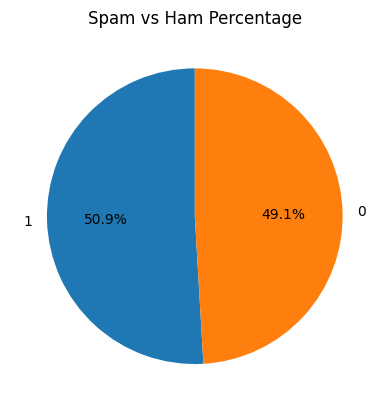

In [210]:
counts = df["Target"].value_counts()
plt.figure()
counts.plot(
    kind='pie',
    autopct='%1.1f%%',   
    startangle=90     
)
plt.title("Spam vs Ham Percentage")
plt.ylabel("")  
plt.show()

In [211]:
df['Word_num'] = df['text'].apply(lambda x: len(nltk.word_tokenize(str(x))))

In [212]:
df

,text,Target,Word_num
0,christmas tree farm pictures,0,4
1,"vastar resources , inc . gary , production fro...",0,1577
2,calpine daily gas nomination - calpine daily g...,0,12
3,re : issue fyi - see note below - already done...,0,347
4,meter 7268 nov allocation fyi .\n- - - - - - -...,0,322
...,...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,1,80
33712,all prescript medicines are on special . to be...,1,182
33713,the next generation online pharmacy . are you ...,1,73
33714,bloow in 5 - 10 times the time learn how to la...,1,28


In [213]:
df['Char_num'] = df['text'].apply(lambda x: len(str(x)))

In [214]:
df

,text,Target,Word_num,Char_num
0,christmas tree farm pictures,0,4,28
1,"vastar resources , inc . gary , production fro...",0,1577,4307
2,calpine daily gas nomination - calpine daily g...,0,12,67
3,re : issue fyi - see note below - already done...,0,347,1182
4,meter 7268 nov allocation fyi .\n- - - - - - -...,0,322,1150
...,...,...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,1,80,364
33712,all prescript medicines are on special . to be...,1,182,903
33713,the next generation online pharmacy . are you ...,1,73,355
33714,bloow in 5 - 10 times the time learn how to la...,1,28,105


In [215]:
df['Sent_num'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(str(x))))

In [216]:
df

,text,Target,Word_num,Char_num,Sent_num
0,christmas tree farm pictures,0,4,28,1
1,"vastar resources , inc . gary , production fro...",0,1577,4307,24
2,calpine daily gas nomination - calpine daily g...,0,12,67,2
3,re : issue fyi - see note below - already done...,0,347,1182,7
4,meter 7268 nov allocation fyi .\n- - - - - - -...,0,322,1150,8
...,...,...,...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,1,80,364,10
33712,all prescript medicines are on special . to be...,1,182,903,17
33713,the next generation online pharmacy . are you ...,1,73,355,7
33714,bloow in 5 - 10 times the time learn how to la...,1,28,105,5


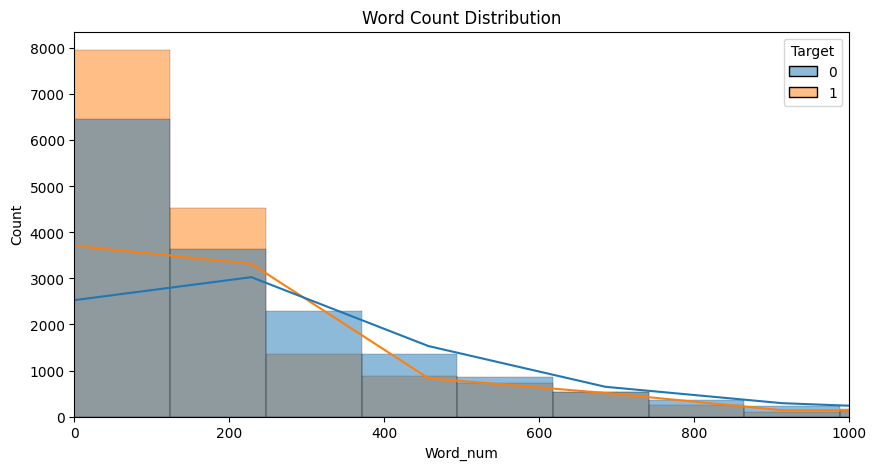

In [217]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Word_num", hue="Target", kde=True)

plt.xlim(0, 1000)
plt.title("Word Count Distribution")
plt.show()

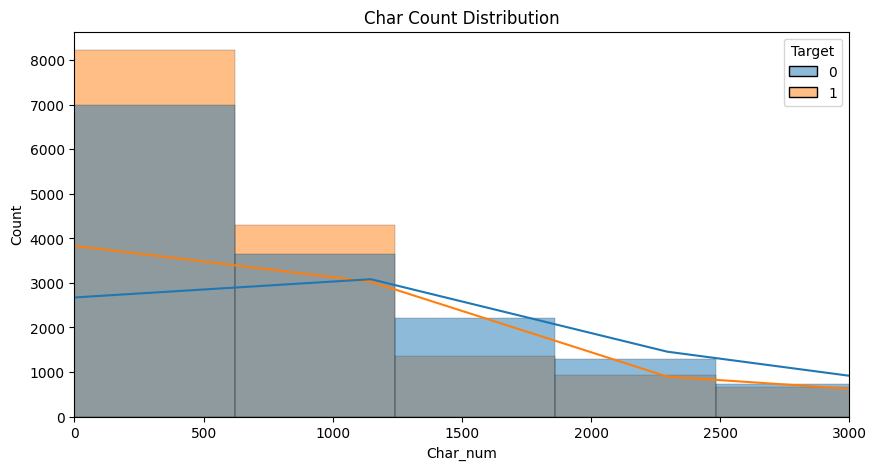

In [218]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Char_num", hue="Target", kde=True)

plt.xlim(0, 3000)
plt.title("Char Count Distribution")
plt.show()

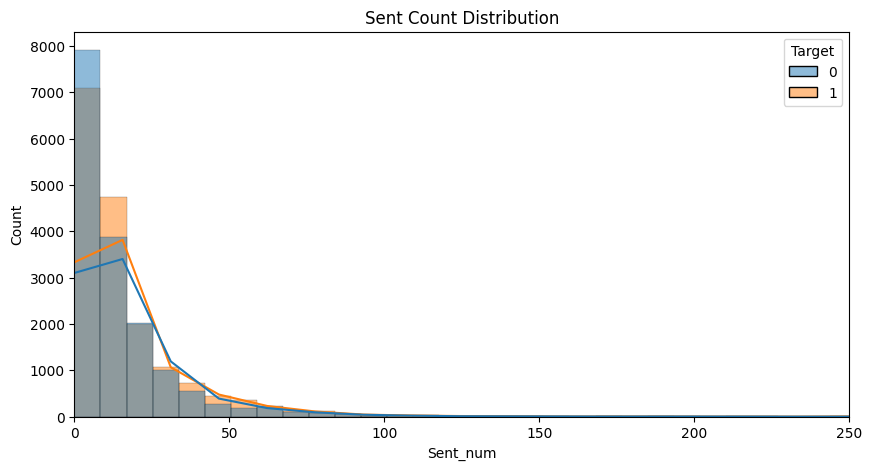

In [219]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Sent_num", hue="Target", kde=True)

plt.xlim(0, 250)
plt.title("Sent Count Distribution")
plt.show()

In [220]:
df_features = df[["Target","Word_num","Char_num","Sent_num"]]

In [221]:
df_features.corr()

,Target,Word_num,Char_num,Sent_num
Target,1.000000,-0.058584,-0.046479,-0.012760
Word_num,-0.058584,1.000000,0.996444,0.861968
Char_num,-0.046479,0.996444,1.000000,0.840067
Sent_num,-0.012760,0.861968,0.840067,1.000000


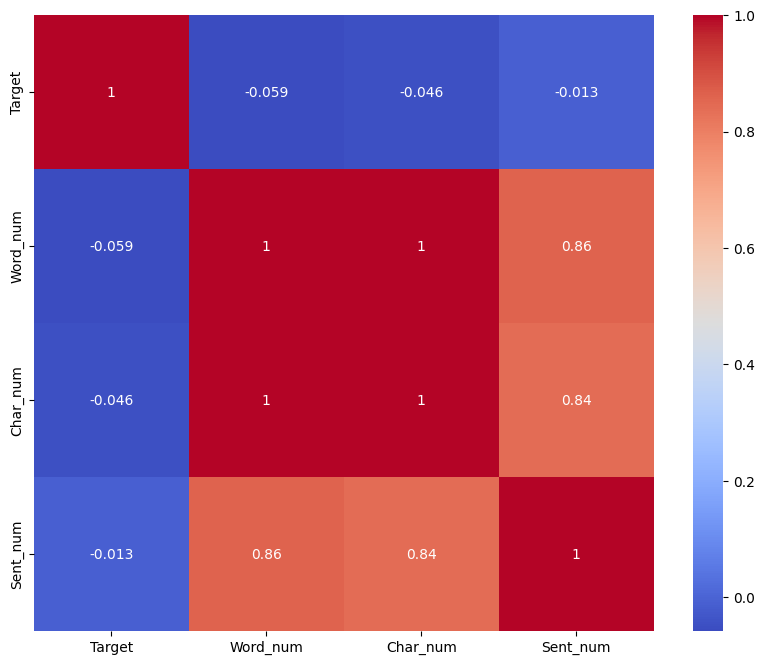

In [222]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm')
plt.show()

In [223]:
corrs = df_features.corr()['Target'].drop('Target').sort_values(ascending=False)

In [224]:
decision_df = pd.DataFrame({
    'Feature': corrs.index,
    'Correlation': corrs.values,
    'Decision': ['Strong' if abs(x) > 0.6 else 'Medium' if abs(x) > 0.4 else 'Weak' for x in corrs]
})

In [225]:
decision_df.style.format({'Correlation': "{:.2f}"})\
    .background_gradient(subset=['Correlation'], cmap='RdYlGn')\
    .hide(axis='index')

Feature,Correlation,Decision
Sent_num,-0.01,Weak
Char_num,-0.05,Weak
Word_num,-0.06,Weak


In [226]:
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
stop = set(stopwords.words("english"))

from nltk.stem import WordNetLemmatizer
ps = WordNetLemmatizer()
punc = string.punctuation

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\oraby\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\oraby\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [227]:
def Process(text):
    text = str(text).lower()  
    tokens = nltk.word_tokenize(text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    filtered = []
    for word in tokens:
        
        if word.isalnum() and word not in stop:
            filtered.append(word)

    lemmas = []
    for word in filtered:
        lemmas.append(ps.lemmatize(word, pos="v"))

    return " ".join(lemmas)

In [228]:
df['New_Text'] = df['text'].apply(Process)

In [229]:
df["New_Text"]   

0                              christmas tree farm picture
1        vastar resources inc gary production high isla...
2        calpine daily gas nomination calpine daily gas...
3        issue fyi see note already do stella forward s...
4        meter 7268 nov allocation fyi forward lauri al...
                               ...                        
33711    iso 8859 1 q good news c edaliss val edumm vl ...
33712    prescript medicine special precise put buck ba...
33713    next generation online pharmacy ready rock let...
33714    bloow 5 10 time time learn last 5 10 time long...
33715    dear sir interest hi need softwares give link ...
Name: New_Text, Length: 33716, dtype: str

In [230]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['New_Text']   
y = df['Target']     

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),   
    min_df=2,            
    max_df=0.9           
)
X_train_tfidf = vectorizer.fit_transform(X_train)  
X_test_tfidf  = vectorizer.transform(X_test)         

In [231]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_tfidf, y_train)

y_pred = dt.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9599644128113879
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3309
           1       0.96      0.96      0.96      3435

    accuracy                           0.96      6744
   macro avg       0.96      0.96      0.96      6744
weighted avg       0.96      0.96      0.96      6744



In [232]:
def predict_message(text, vectorizer, model):
    text = Process(text)   
    
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)[0]

    return "Spam" if prediction == 1 else "Ham"

In [233]:
msg1 = "FREE entry!!! WIN cash now!!! call 09061701461"
msg2 = "Don't forget to bring your notebook tomorrow"

print("Message 1:", msg1)
print("Prediction:", predict_message(msg1, vectorizer, dt))

print("Message 2:", msg2)
print("Prediction:", predict_message(msg2, vectorizer, dt))

Message 1: FREE entry!!! WIN cash now!!! call 09061701461
Prediction: Spam
Message 2: Don't forget to bring your notebook tomorrow
Prediction: Ham


In [234]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9900652431791221
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3309
           1       0.98      1.00      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



In [235]:
msg1 = "Congratulations! You won a free iPhone. Click now!"
msg2 = "Don't forget to bring your notebook tomorrow"

print("Message 1:", msg1)
print("Prediction:", predict_message(msg1, vectorizer, lr))

print("Message 2:", msg2)
print("Prediction:", predict_message(msg2, vectorizer, lr))

Message 1: Congratulations! You won a free iPhone. Click now!
Prediction: Spam
Message 2: Don't forget to bring your notebook tomorrow
Prediction: Ham


In [236]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred = nb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.984282325029656
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3309
           1       0.98      0.99      0.98      3435

    accuracy                           0.98      6744
   macro avg       0.98      0.98      0.98      6744
weighted avg       0.98      0.98      0.98      6744



In [237]:
msg1 = "Congratulations! You won a free iPhone. Click now!"
msg2 = "Don't forget to bring your notebook tomorrow"

print("Message 1:", msg1)
print("Prediction:", predict_message(msg1, vectorizer, nb))

print("Message 2:", msg2)
print("Prediction:", predict_message(msg2, vectorizer, nb))

Message 1: Congratulations! You won a free iPhone. Click now!
Prediction: Spam
Message 2: Don't forget to bring your notebook tomorrow
Prediction: Ham


In [238]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)

y_pred = rf.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9875444839857651
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3309
           1       0.98      0.99      0.99      3435

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



In [239]:
msg1 = "Congratulations! You won a free iPhone. Click now!"
msg2 = "Don't forget to bring your notebook tomorrow"

print("Message 1:", msg1)
print("Prediction:", predict_message(msg1, vectorizer, rf))

print("Message 2:", msg2)
print("Prediction:", predict_message(msg2, vectorizer, rf))

Message 1: Congratulations! You won a free iPhone. Click now!
Prediction: Spam
Message 2: Don't forget to bring your notebook tomorrow
Prediction: Ham


In [240]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm = LinearSVC(max_iter=2000)
svm.fit(X_test_tfidf, y_test)
y_pred = svm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9991103202846975
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3309
           1       1.00      1.00      1.00      3435

    accuracy                           1.00      6744
   macro avg       1.00      1.00      1.00      6744
weighted avg       1.00      1.00      1.00      6744



In [241]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf,
    "Decision Tree": dt
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("📊 All Models Performance:\n")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1 Score"]

print("\n" + "="*50)
print(f"🏆 Best Model: {best_model_name}")
print(f"🔥 Best F1 Score: {best_f1:.4f}")

📊 All Models Performance:

                 Model  Accuracy  Precision    Recall  F1 Score
2                  SVM  0.999110   0.998256  1.000000  0.999127
1  Logistic Regression  0.990065   0.983075  0.997671  0.990319
3        Random Forest  0.987544   0.984389  0.991266  0.987815
0          Naive Bayes  0.984282   0.977893  0.991557  0.984678
4        Decision Tree  0.959964   0.963126  0.958079  0.960595

🏆 Best Model: SVM
🔥 Best F1 Score: 0.9991


In [242]:
print(predict_message("Congratulations! You won a free iPhone. Click now!", vectorizer, svm))
print(predict_message("Don't forget to bring your notebook tomorrow", vectorizer, svm))

Spam
Spam


In [243]:
import joblib

for name, model in models.items():
    filename = f'spam_model_{name.replace(" ", "_").lower()}.pkl'
    joblib.dump(model, filename)
    print(f"Model '{name}' saved as '{filename}'")
    
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("\nVectorizer saved successfully!")

Model 'Naive Bayes' saved as 'spam_model_naive_bayes.pkl'
Model 'Logistic Regression' saved as 'spam_model_logistic_regression.pkl'
Model 'SVM' saved as 'spam_model_svm.pkl'
Model 'Random Forest' saved as 'spam_model_random_forest.pkl'
Model 'Decision Tree' saved as 'spam_model_decision_tree.pkl'

Vectorizer saved successfully!
